# AI Safety, Alignment & Robustness

As AI systems become more powerful and widely deployed, safety is paramount.
This notebook covers adversarial attacks, robustness, alignment concepts,
and evaluation techniques — all critical for responsible AI engineering.

**Prerequisites:**
```bash
pip install numpy matplotlib scikit-learn pandas
```

📺 **Video Lecture:** [https://youtu.be/yvHFDGLkzws](https://youtu.be/yvHFDGLkzws)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
np.random.seed(42)

print('Libraries loaded!')

Libraries loaded!


## 1. Adversarial Examples

Small, carefully crafted perturbations to inputs that cause models to
make confident but wrong predictions. This is a fundamental vulnerability
in neural networks.

Clean accuracy: 1.000
Adversarial accuracy: 0.547
Accuracy drop: 0.453


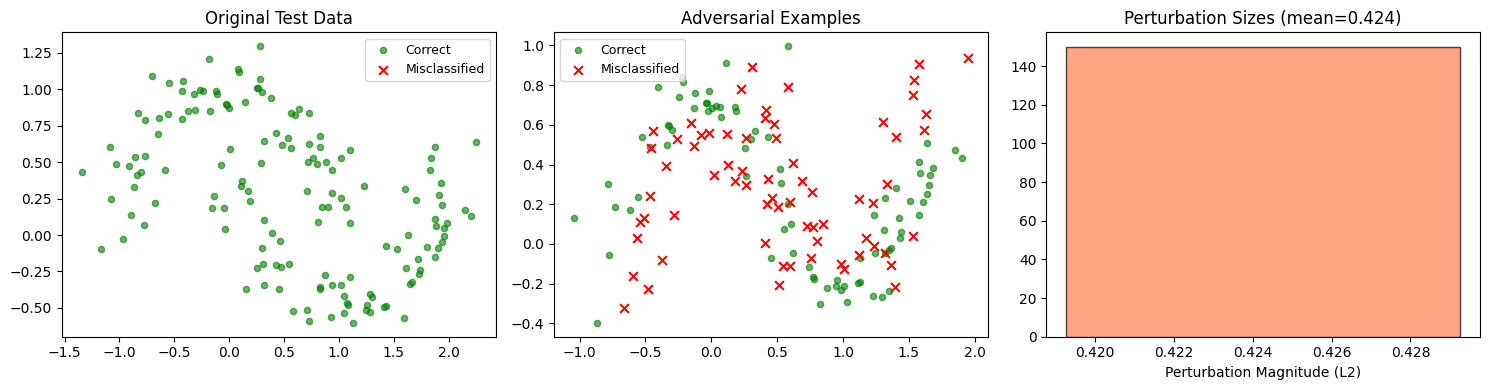

In [3]:
# Train a model on the moons dataset
X, y = make_moons(n_samples=500, noise=0.15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)
model.fit(X_train, y_train)
print(f'Clean accuracy: {accuracy_score(y_test, model.predict(X_test)):.3f}')

# FGSM-inspired adversarial attack (simplified for sklearn)
def create_adversarial_examples(model, X, y, epsilon=0.3):
    """
    Create adversarial examples using gradient-like perturbations.
    For sklearn MLP, we approximate gradients with finite differences.
    """
    X_adv = X.copy()
    delta = 1e-4
    
    for i in range(len(X)):
        grad = np.zeros(X.shape[1])
        base_prob = model.predict_proba(X[i:i+1])[0, y[i]]
        
        for j in range(X.shape[1]):
            X_plus = X[i].copy()
            X_plus[j] += delta
            prob_plus = model.predict_proba(X_plus.reshape(1, -1))[0, y[i]]
            grad[j] = (prob_plus - base_prob) / delta
        
        # Perturb in direction that DECREASES correct class probability
        perturbation = -epsilon * np.sign(grad)
        X_adv[i] += perturbation
    
    return X_adv

# Generate adversarial examples
X_adv = create_adversarial_examples(model, X_test, y_test, epsilon=0.3)
adv_accuracy = accuracy_score(y_test, model.predict(X_adv))

print(f'Adversarial accuracy: {adv_accuracy:.3f}')
print(f'Accuracy drop: {accuracy_score(y_test, model.predict(X_test)) - adv_accuracy:.3f}')

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, data, title in [
    (axes[0], X_test, 'Original Test Data'),
    (axes[1], X_adv, 'Adversarial Examples'),
]:
    preds = model.predict(data)
    correct = preds == y_test
    ax.scatter(data[correct, 0], data[correct, 1], c='green', s=20, alpha=0.6, label='Correct')
    ax.scatter(data[~correct, 0], data[~correct, 1], c='red', s=40, marker='x',
              linewidths=1.5, label='Misclassified')
    ax.set_title(title); ax.legend(fontsize=9)

# Show perturbation magnitudes
perturbations = np.linalg.norm(X_adv - X_test, axis=1)
if perturbations.max() - perturbations.min() < 1e-10:
    axes[2].bar([perturbations.mean()], [len(perturbations)], width=0.01, color='coral', edgecolor='black', alpha=0.7)
else:
    axes[2].hist(perturbations, bins=min(5, max(1, len(np.unique(np.round(perturbations, 6))))), color='coral', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Perturbation Magnitude (L2)')
axes[2].set_title(f'Perturbation Sizes (mean={perturbations.mean():.3f})')

plt.tight_layout(); plt.show()

## 2. Robustness Under Distribution Shift

Real-world models face data that differs from training.
How gracefully does performance degrade?

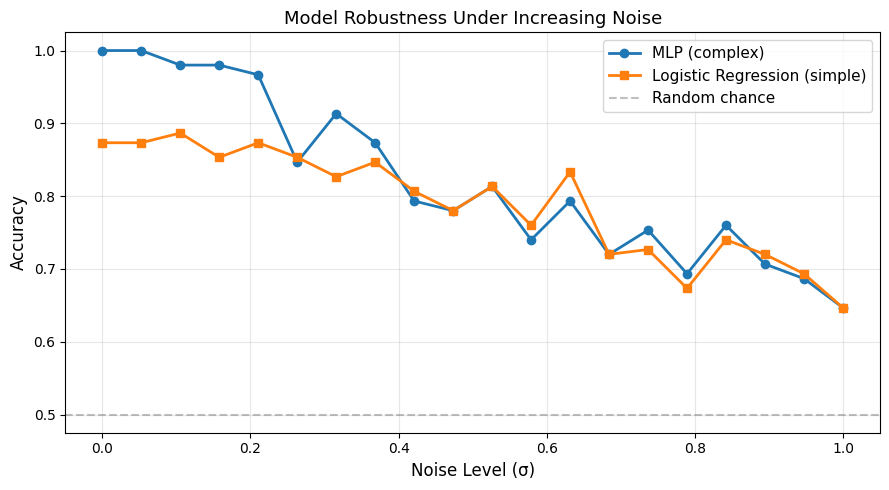

Note: Simpler models can sometimes be MORE robust to noise!


In [4]:
# Test robustness under increasing noise levels
noise_levels = np.linspace(0, 1.0, 20)
accuracies_mlp = []
accuracies_lr = []

# Also train a simpler logistic regression for comparison
lr_model = LogisticRegression(max_iter=200).fit(X_train, y_train)

for noise in noise_levels:
    X_noisy = X_test + np.random.randn(*X_test.shape) * noise
    accuracies_mlp.append(accuracy_score(y_test, model.predict(X_noisy)))
    accuracies_lr.append(accuracy_score(y_test, lr_model.predict(X_noisy)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(noise_levels, accuracies_mlp, 'o-', label='MLP (complex)', linewidth=2)
ax.plot(noise_levels, accuracies_lr, 's-', label='Logistic Regression (simple)', linewidth=2)
ax.axhline(y=0.5, linestyle='--', color='gray', alpha=0.5, label='Random chance')
ax.set_xlabel('Noise Level (σ)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Robustness Under Increasing Noise', fontsize=13)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print('Note: Simpler models can sometimes be MORE robust to noise!')

## 3. Model Calibration

A well-calibrated model's confidence reflects actual accuracy.
If it says "90% confident", it should be right ~90% of the time.
Miscalibrated models are a safety risk — overconfident wrong predictions.

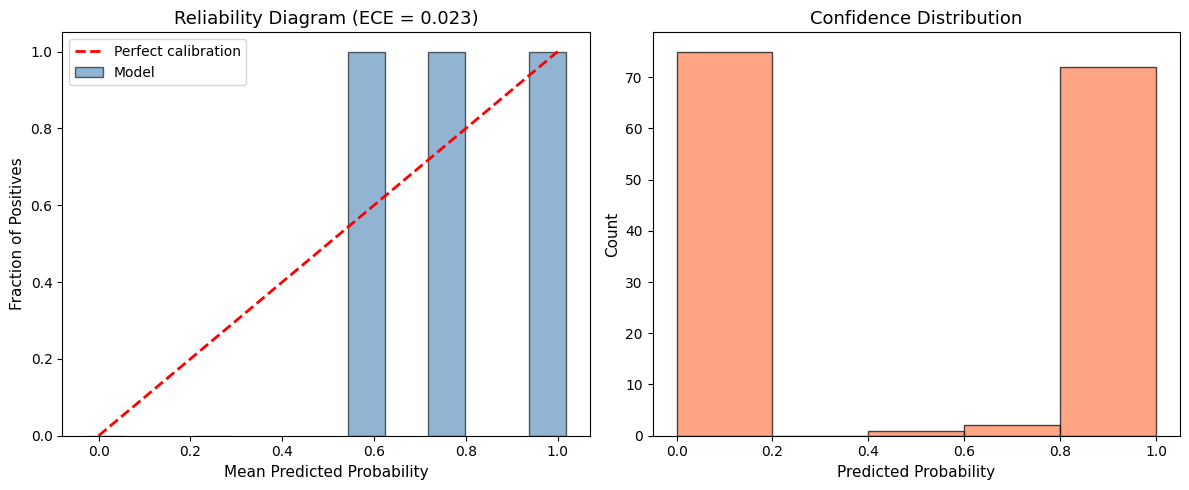

Expected Calibration Error (ECE): 0.023
Lower ECE = better calibrated. Fix with temperature scaling or Platt scaling.


In [5]:
# Evaluate calibration using reliability diagram
def calibration_curve(model, X, y, n_bins=5):
    """Compute calibration curve and Expected Calibration Error (ECE)."""
    probs = model.predict_proba(X)[:, 1]
    bin_edges = np.linspace(0, 1, n_bins + 1)
    
    bin_confidences = []
    bin_accuracies = []
    bin_counts = []
    
    for i in range(n_bins):
        mask = (probs >= bin_edges[i]) & (probs < bin_edges[i+1])
        if mask.sum() > 0:
            bin_confidences.append(probs[mask].mean())
            bin_accuracies.append(y[mask].mean())
            bin_counts.append(mask.sum())
        else:
            bin_confidences.append(bin_edges[i] + 0.05)
            bin_accuracies.append(0)
            bin_counts.append(0)
    
    # Expected Calibration Error
    total = sum(bin_counts)
    ece = sum(abs(a - c) * n / total
             for a, c, n in zip(bin_accuracies, bin_confidences, bin_counts)
             if n > 0)
    
    return bin_confidences, bin_accuracies, bin_counts, ece

conf, acc, counts, ece = calibration_curve(model, X_test, y_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Reliability diagram
axes[0].bar(conf, acc, width=0.08, alpha=0.6, color='steelblue',
           edgecolor='black', label='Model')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect calibration')
axes[0].set_xlabel('Mean Predicted Probability', fontsize=11)
axes[0].set_ylabel('Fraction of Positives', fontsize=11)
axes[0].set_title(f'Reliability Diagram (ECE = {ece:.3f})', fontsize=13)
axes[0].legend(fontsize=10)

# Confidence distribution
probs = model.predict_proba(X_test)[:, 1]
if probs.max() - probs.min() < 1e-10:
    axes[1].bar([probs.mean()], [len(probs)], width=0.01, edgecolor='black', alpha=0.7, color='coral')
else:
    axes[1].hist(probs, bins=min(5, max(1, len(np.unique(np.round(probs, 6))))), edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Predicted Probability', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Confidence Distribution', fontsize=13)

plt.tight_layout(); plt.show()
print(f'Expected Calibration Error (ECE): {ece:.3f}')
print('Lower ECE = better calibrated. Fix with temperature scaling or Platt scaling.')

## 4. Fairness & Bias in ML Models

ML models can perpetuate or amplify societal biases present in training data.
Measuring and mitigating bias is an essential safety concern.

=== Fairness Analysis ===
Positive rate (Female): 0.255
Positive rate (Male):   0.766
Demographic Parity Ratio: 0.333 (1.0 = fair, <0.8 = potential issue)

TPR Female: 1.000
TPR Male:   0.973
Equal Opportunity Difference: 0.027


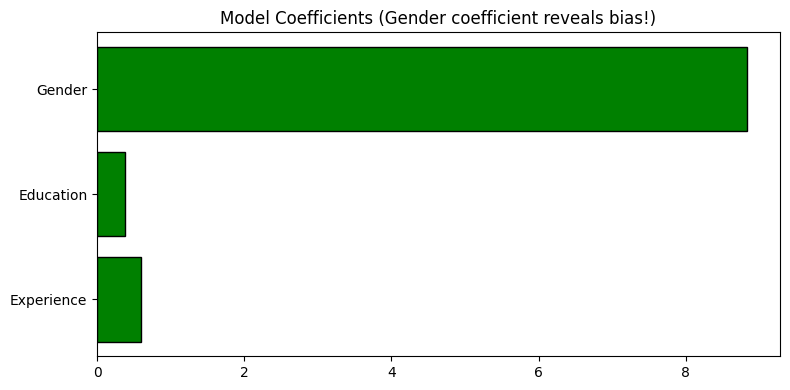

In [6]:
# Simulate a hiring model with potential gender bias
np.random.seed(42)
n = 1000

# Features: [experience_years, education_score, gender (0=F, 1=M)]
experience = np.random.exponential(5, n)
education = np.random.normal(70, 15, n)
gender = np.random.choice([0, 1], n)  # 0=Female, 1=Male

# Historical hiring decisions (biased — gender influences outcome)
score = 0.3 * experience + 0.2 * education + 5 * gender  # bias!
hired = (score > np.median(score)).astype(int)

X_hire = np.column_stack([experience, education, gender])
model_biased = LogisticRegression(max_iter=200).fit(X_hire, hired)

# Fairness metrics
preds = model_biased.predict(X_hire)

# Demographic Parity: P(Y_hat=1 | A=0) vs P(Y_hat=1 | A=1)
rate_female = preds[gender == 0].mean()
rate_male = preds[gender == 1].mean()
dp_ratio = rate_female / rate_male

# Equal Opportunity: TPR for each group
tpr_female = preds[(gender == 0) & (hired == 1)].mean()
tpr_male = preds[(gender == 1) & (hired == 1)].mean()

print('=== Fairness Analysis ===')
print(f'Positive rate (Female): {rate_female:.3f}')
print(f'Positive rate (Male):   {rate_male:.3f}')
print(f'Demographic Parity Ratio: {dp_ratio:.3f} (1.0 = fair, <0.8 = potential issue)')
print(f'\nTPR Female: {tpr_female:.3f}')
print(f'TPR Male:   {tpr_male:.3f}')
print(f'Equal Opportunity Difference: {abs(tpr_female - tpr_male):.3f}')

# Feature importance reveals bias
feature_names = ['Experience', 'Education', 'Gender']
fig, ax = plt.subplots(figsize=(8, 4))
coefs = model_biased.coef_[0]
colors = ['green' if c > 0 else 'red' for c in coefs]
ax.barh(feature_names, coefs, color=colors, edgecolor='black')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_title('Model Coefficients (Gender coefficient reveals bias!)', fontsize=12)
plt.tight_layout(); plt.show()

## 5. Bias Mitigation Strategies

Three approaches to reduce bias:
- **Pre-processing**: fix the training data
- **In-processing**: add fairness constraints during training
- **Post-processing**: adjust predictions after training

In [7]:
# Strategy 1: Remove protected attribute (simple but imperfect)
X_no_gender = X_hire[:, :2]  # drop gender column
model_fair_v1 = LogisticRegression(max_iter=200).fit(X_no_gender, hired)
preds_v1 = model_fair_v1.predict(X_no_gender)

rate_f_v1 = preds_v1[gender == 0].mean()
rate_m_v1 = preds_v1[gender == 1].mean()

# Strategy 2: Threshold adjustment (post-processing)
probs_biased = model_biased.predict_proba(X_hire)[:, 1]
# Use different thresholds for each group to equalize rates
threshold_f = np.percentile(probs_biased[gender == 0], 50)
threshold_m = np.percentile(probs_biased[gender == 1], 50)
preds_v2 = np.where(gender == 0,
                    (probs_biased > threshold_f).astype(int),
                    (probs_biased > threshold_m).astype(int))
rate_f_v2 = preds_v2[gender == 0].mean()
rate_m_v2 = preds_v2[gender == 1].mean()

print('=== Bias Mitigation Comparison ===')
print(f"{'Method':<25} {'Rate(F)':<10} {'Rate(M)':<10} {'DP Ratio':<10}")
print('-' * 55)
print(f"{'Original (biased)':<25} {rate_female:<10.3f} {rate_male:<10.3f} {dp_ratio:<10.3f}")
print(f"{'Remove gender feature':<25} {rate_f_v1:<10.3f} {rate_m_v1:<10.3f} {rate_f_v1/rate_m_v1:<10.3f}")
print(f"{'Threshold adjustment':<25} {rate_f_v2:<10.3f} {rate_m_v2:<10.3f} {rate_f_v2/(rate_m_v2+1e-8):<10.3f}")
print(f'\n→ Both strategies improve fairness, but with different tradeoffs')

=== Bias Mitigation Comparison ===
Method                    Rate(F)    Rate(M)    DP Ratio  
-------------------------------------------------------
Original (biased)         0.255      0.766      0.333     
Remove gender feature     0.487      0.483      1.007     
Threshold adjustment      0.500      0.500      1.000     

→ Both strategies improve fairness, but with different tradeoffs


## 6. RLHF & Alignment Concepts

**Alignment** ensures AI systems behave as intended. For LLMs, RLHF
(Reinforcement Learning from Human Feedback) is the dominant approach.

=== RLHF Pipeline ===

Phase 1: Supervised Fine-Tuning (SFT)
  - Start with a pretrained language model
  - Fine-tune on high-quality demonstrations
  - Result: model that follows instructions
  - Quality score: 0.6/1.0

Phase 2: Reward Model Training
  - Collect human preference comparisons
  - Train a model to predict which response humans prefer
  - 1000 preference pairs collected
  - Humans preferred response A 74% of the time

Phase 3: RL Optimization (PPO)
  - Use reward model as the reward signal
  - Optimize policy while staying close to SFT model (KL constraint)
  - Final quality: 0.75/1.0


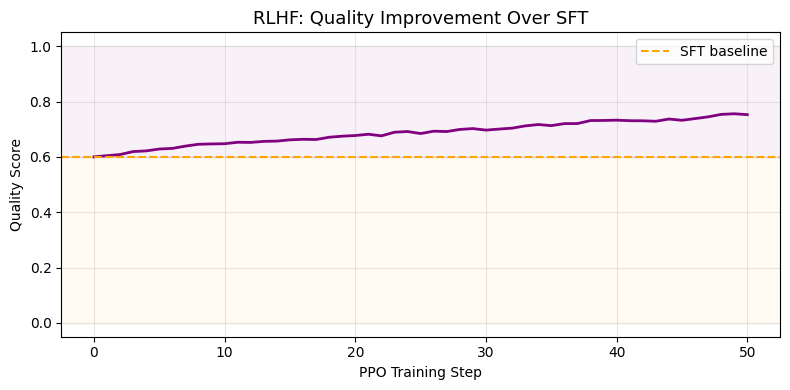

In [8]:
# Simulate the RLHF pipeline
def simulate_rlhf():
    """
    RLHF has 3 phases:
    1. Supervised Fine-Tuning (SFT)
    2. Reward Model Training
    3. RL Optimization (PPO)
    """
    print('=== RLHF Pipeline ===')
    print()
    
    # Phase 1: SFT
    print('Phase 1: Supervised Fine-Tuning (SFT)')
    print('  - Start with a pretrained language model')
    print('  - Fine-tune on high-quality demonstrations')
    print('  - Result: model that follows instructions')
    sft_quality = 0.6
    print(f'  - Quality score: {sft_quality:.1f}/1.0\n')
    
    # Phase 2: Reward Model
    print('Phase 2: Reward Model Training')
    print('  - Collect human preference comparisons')
    print('  - Train a model to predict which response humans prefer')
    
    # Simulate preference data
    n_comparisons = 1000
    response_a_quality = np.random.beta(3, 2, n_comparisons)  # response A scores
    response_b_quality = np.random.beta(2, 3, n_comparisons)  # response B scores
    human_prefers_a = (response_a_quality > response_b_quality).astype(int)
    print(f'  - {n_comparisons} preference pairs collected')
    print(f'  - Humans preferred response A {human_prefers_a.mean()*100:.0f}% of the time\n')
    
    # Phase 3: PPO Optimization
    print('Phase 3: RL Optimization (PPO)')
    print('  - Use reward model as the reward signal')
    print('  - Optimize policy while staying close to SFT model (KL constraint)')
    
    # Simulate RL training improving quality
    epochs = 50
    quality = sft_quality
    qualities = [quality]
    for e in range(epochs):
        improvement = 0.008 * (1 - quality)  # diminishing returns
        quality += improvement + np.random.randn() * 0.005
        quality = min(quality, 0.95)  # cap
        qualities.append(quality)
    
    print(f'  - Final quality: {qualities[-1]:.2f}/1.0')
    return qualities

qualities = simulate_rlhf()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(qualities, linewidth=2, color='purple')
ax.axhline(y=0.6, linestyle='--', color='orange', label='SFT baseline')
ax.axhspan(0, 0.6, alpha=0.05, color='orange')
ax.axhspan(0.6, 1.0, alpha=0.05, color='purple')
ax.set_xlabel('PPO Training Step'); ax.set_ylabel('Quality Score')
ax.set_title('RLHF: Quality Improvement Over SFT', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 7. AI Safety Taxonomy

A structured view of safety concerns across the AI lifecycle.

In [9]:
safety_taxonomy = pd.DataFrame({
    'Category': [
        'Robustness', 'Robustness',
        'Alignment', 'Alignment',
        'Fairness', 'Fairness',
        'Privacy', 'Privacy',
        'Security', 'Security',
    ],
    'Risk': [
        'Adversarial attacks', 'Distribution shift',
        'Reward hacking', 'Goal misspecification',
        'Demographic bias', 'Representation harm',
        'Data memorization', 'Membership inference',
        'Prompt injection', 'Model extraction',
    ],
    'Mitigation': [
        'Adversarial training, certified defenses', 'Domain adaptation, monitoring',
        'RLHF, constitutional AI, KL constraints', 'Careful reward design, human oversight',
        'Fairness constraints, auditing', 'Diverse training data, debiasing',
        'Differential privacy, data deduplication', 'Privacy-preserving ML',
        'Input filtering, system prompts', 'Rate limiting, watermarking',
    ],
})
print(safety_taxonomy.to_string(index=False))

  Category                  Risk                               Mitigation
Robustness   Adversarial attacks Adversarial training, certified defenses
Robustness    Distribution shift            Domain adaptation, monitoring
 Alignment        Reward hacking  RLHF, constitutional AI, KL constraints
 Alignment Goal misspecification   Careful reward design, human oversight
  Fairness      Demographic bias           Fairness constraints, auditing
  Fairness   Representation harm         Diverse training data, debiasing
   Privacy     Data memorization Differential privacy, data deduplication
   Privacy  Membership inference                    Privacy-preserving ML
  Security      Prompt injection          Input filtering, system prompts
  Security      Model extraction              Rate limiting, watermarking


## 8. Interview Takeaways

**Critical safety concepts:**

- **Adversarial examples**: tiny perturbations fool models confidently → defend with adversarial training
- **Robustness**: test performance under noise, shift, and edge cases
- **Calibration**: confidence should match accuracy → use temperature/Platt scaling
- **Fairness**: demographic parity, equalized odds, individual fairness
- **RLHF**: SFT → Reward Model → PPO — the standard LLM alignment pipeline
- **Constitutional AI**: self-critique + revision as an alternative to RLHF
- **Red teaming**: proactively find failure modes before deployment
- **Guardrails**: input/output filters, content classifiers, system prompts
- The field is evolving rapidly — stay current with safety research

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>